In [18]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

In [19]:
import numpy as np

# === Load Raw Data ===
ambient_vib_pcb = np.load("ambient_vib_pcb.npy")
ambient_vib_wsn = np.load("ambient_vib_wsn.npy")
free_vib_pcb = np.load("free_vib_pcb.npy")
free_vib_wsn = np.load("free_vib_wsn.npy")

# === Transform Function: Convert PCB to WSN-Aligned Coordinate System ===
def transform_pcb_to_wsn(pcb_data):
    transformed = np.empty_like(pcb_data)
    for sensor_index in range(4):
        base = sensor_index * 3
        pcb_x = pcb_data[:, base + 0]
        pcb_y = pcb_data[:, base + 1]
        pcb_z = pcb_data[:, base + 2]

        # Coordinate transformation:
        # WSN_X = -PCB_Y
        # WSN_Y =  PCB_X
        # WSN_Z =  PCB_Z
        transformed[:, base + 0] = -pcb_y  # WSN X
        transformed[:, base + 1] =  pcb_x  # WSN Y
        transformed[:, base + 2] =  pcb_z  # WSN Z
    return transformed

# === Generate Aligned Versions ===
am_pcb_aligned   = transform_pcb_to_wsn(ambient_vib_pcb)
am_wsn_aligned   = ambient_vib_wsn.copy()

free_pcb_aligned = transform_pcb_to_wsn(free_vib_pcb)
free_wsn_aligned = free_vib_wsn.copy()

# === (Optional) Confirm Shapes Match ===
print("am_pcb_aligned:   ", am_pcb_aligned.shape)
print("am_wsn_aligned:   ", am_wsn_aligned.shape)
print("free_pcb_aligned: ", free_pcb_aligned.shape)
print("free_wsn_aligned: ", free_wsn_aligned.shape)


am_pcb_aligned:    (614400, 12)
am_wsn_aligned:    (41999, 12)
free_pcb_aligned:  (614400, 12)
free_wsn_aligned:  (29999, 12)


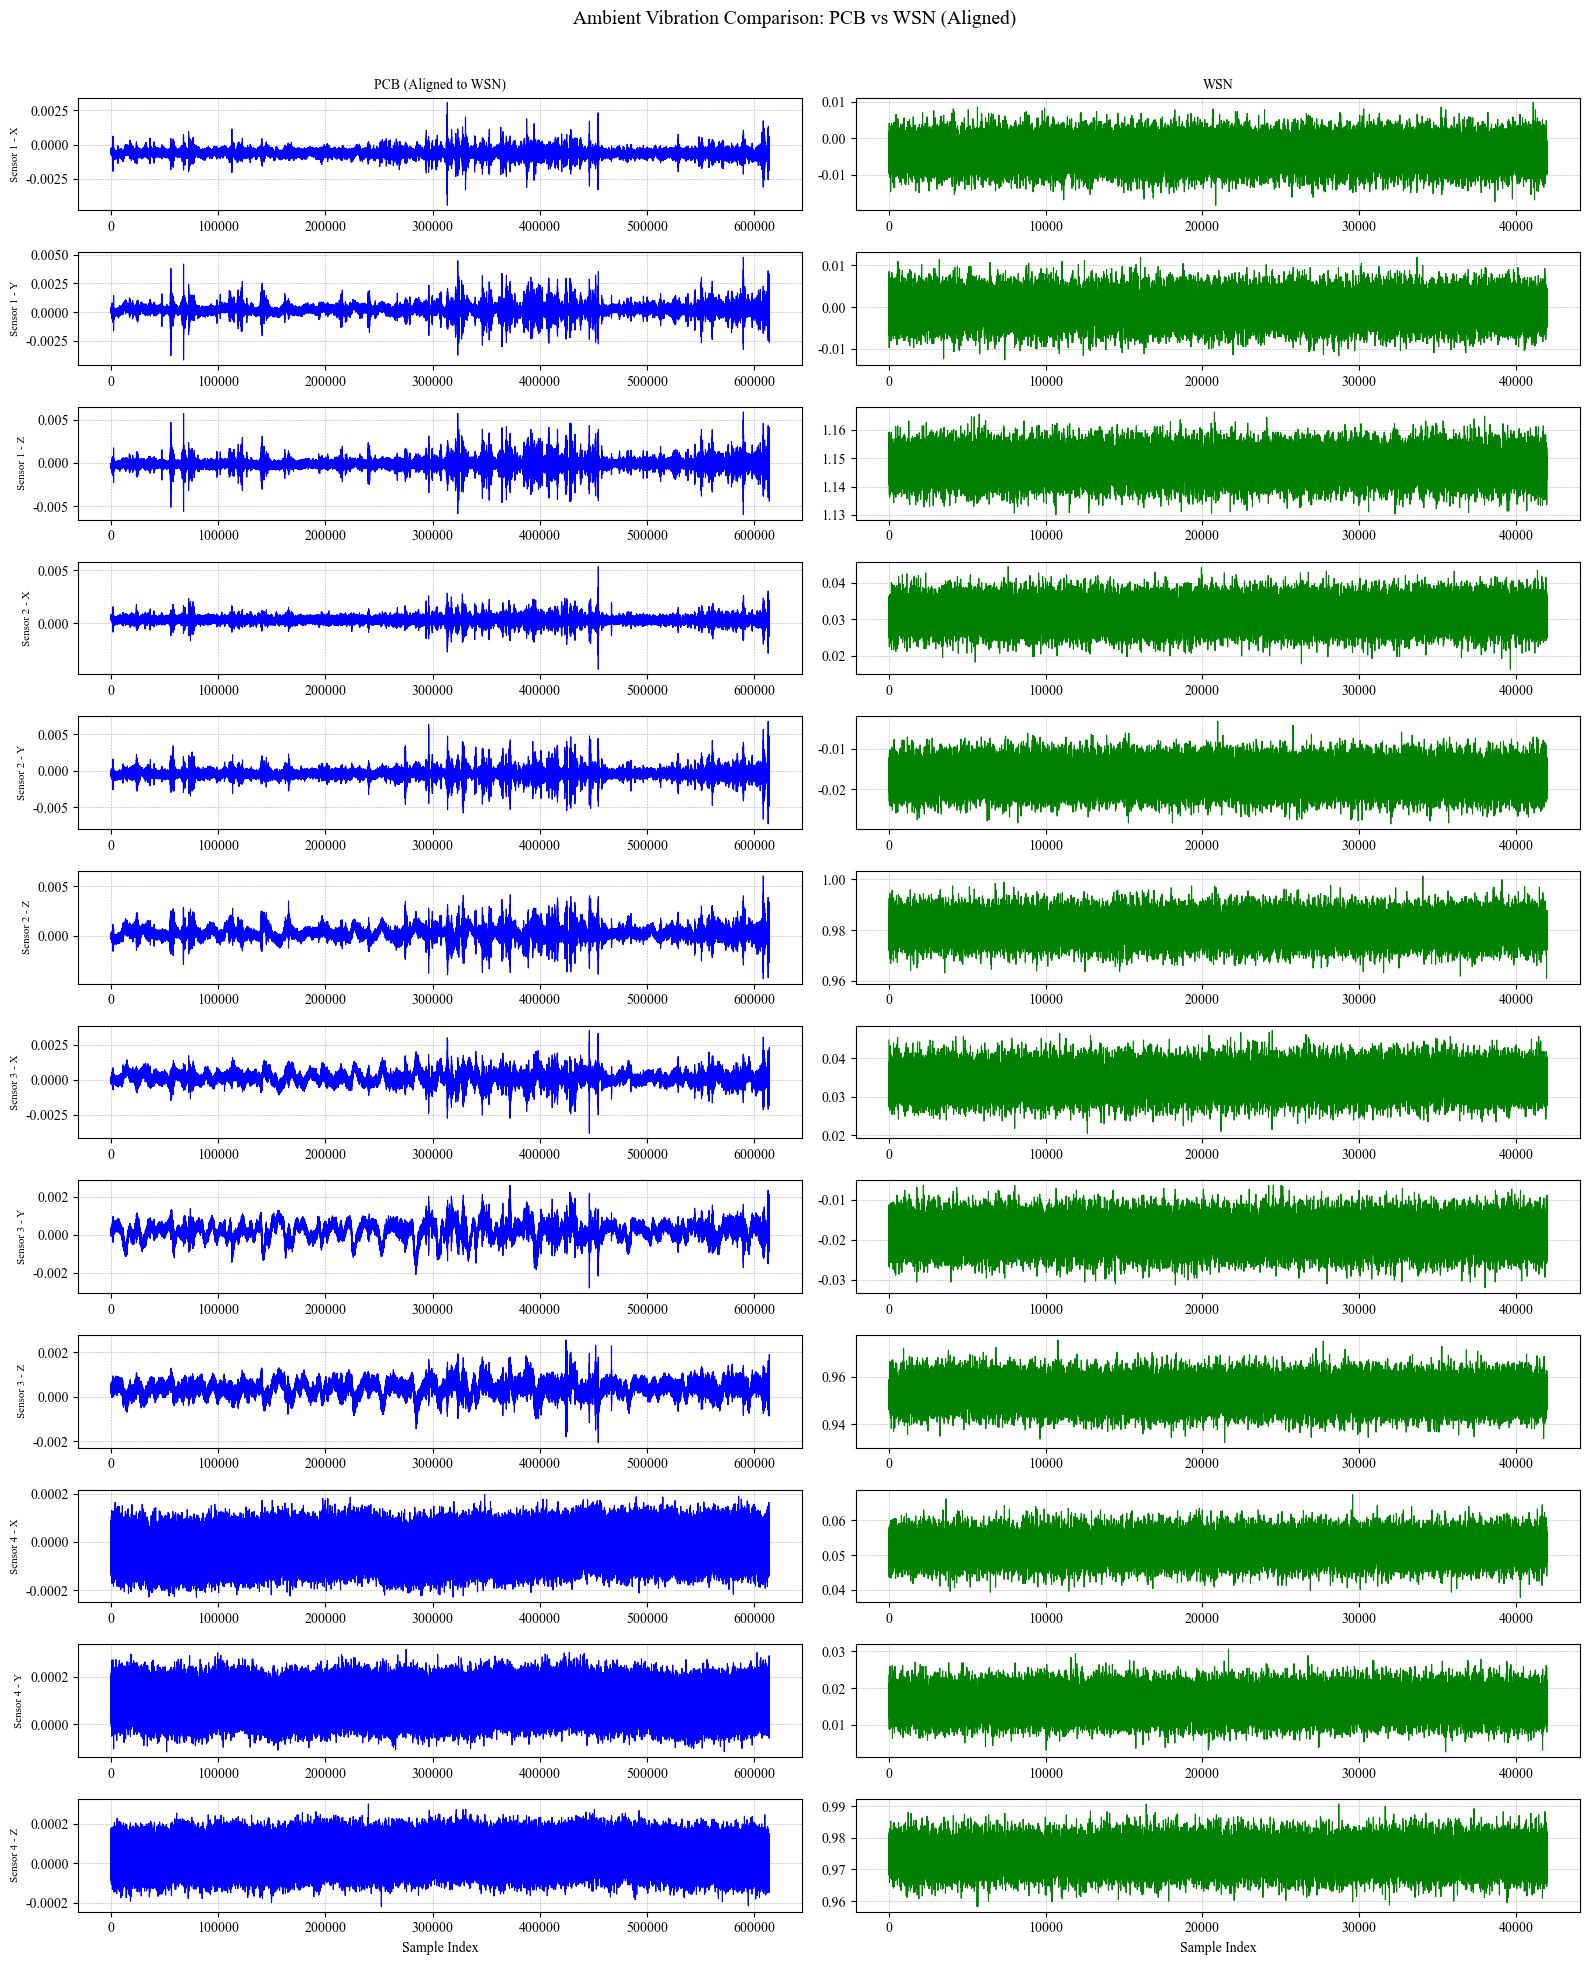

In [20]:
# === Time Axes (independent) ===
time_pcb_am = np.arange(am_pcb_aligned.shape[0])
time_wsn_am = np.arange(am_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB (Aligned)
    axes[i, 0].plot(time_pcb_am, am_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn_am, am_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Ambient Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


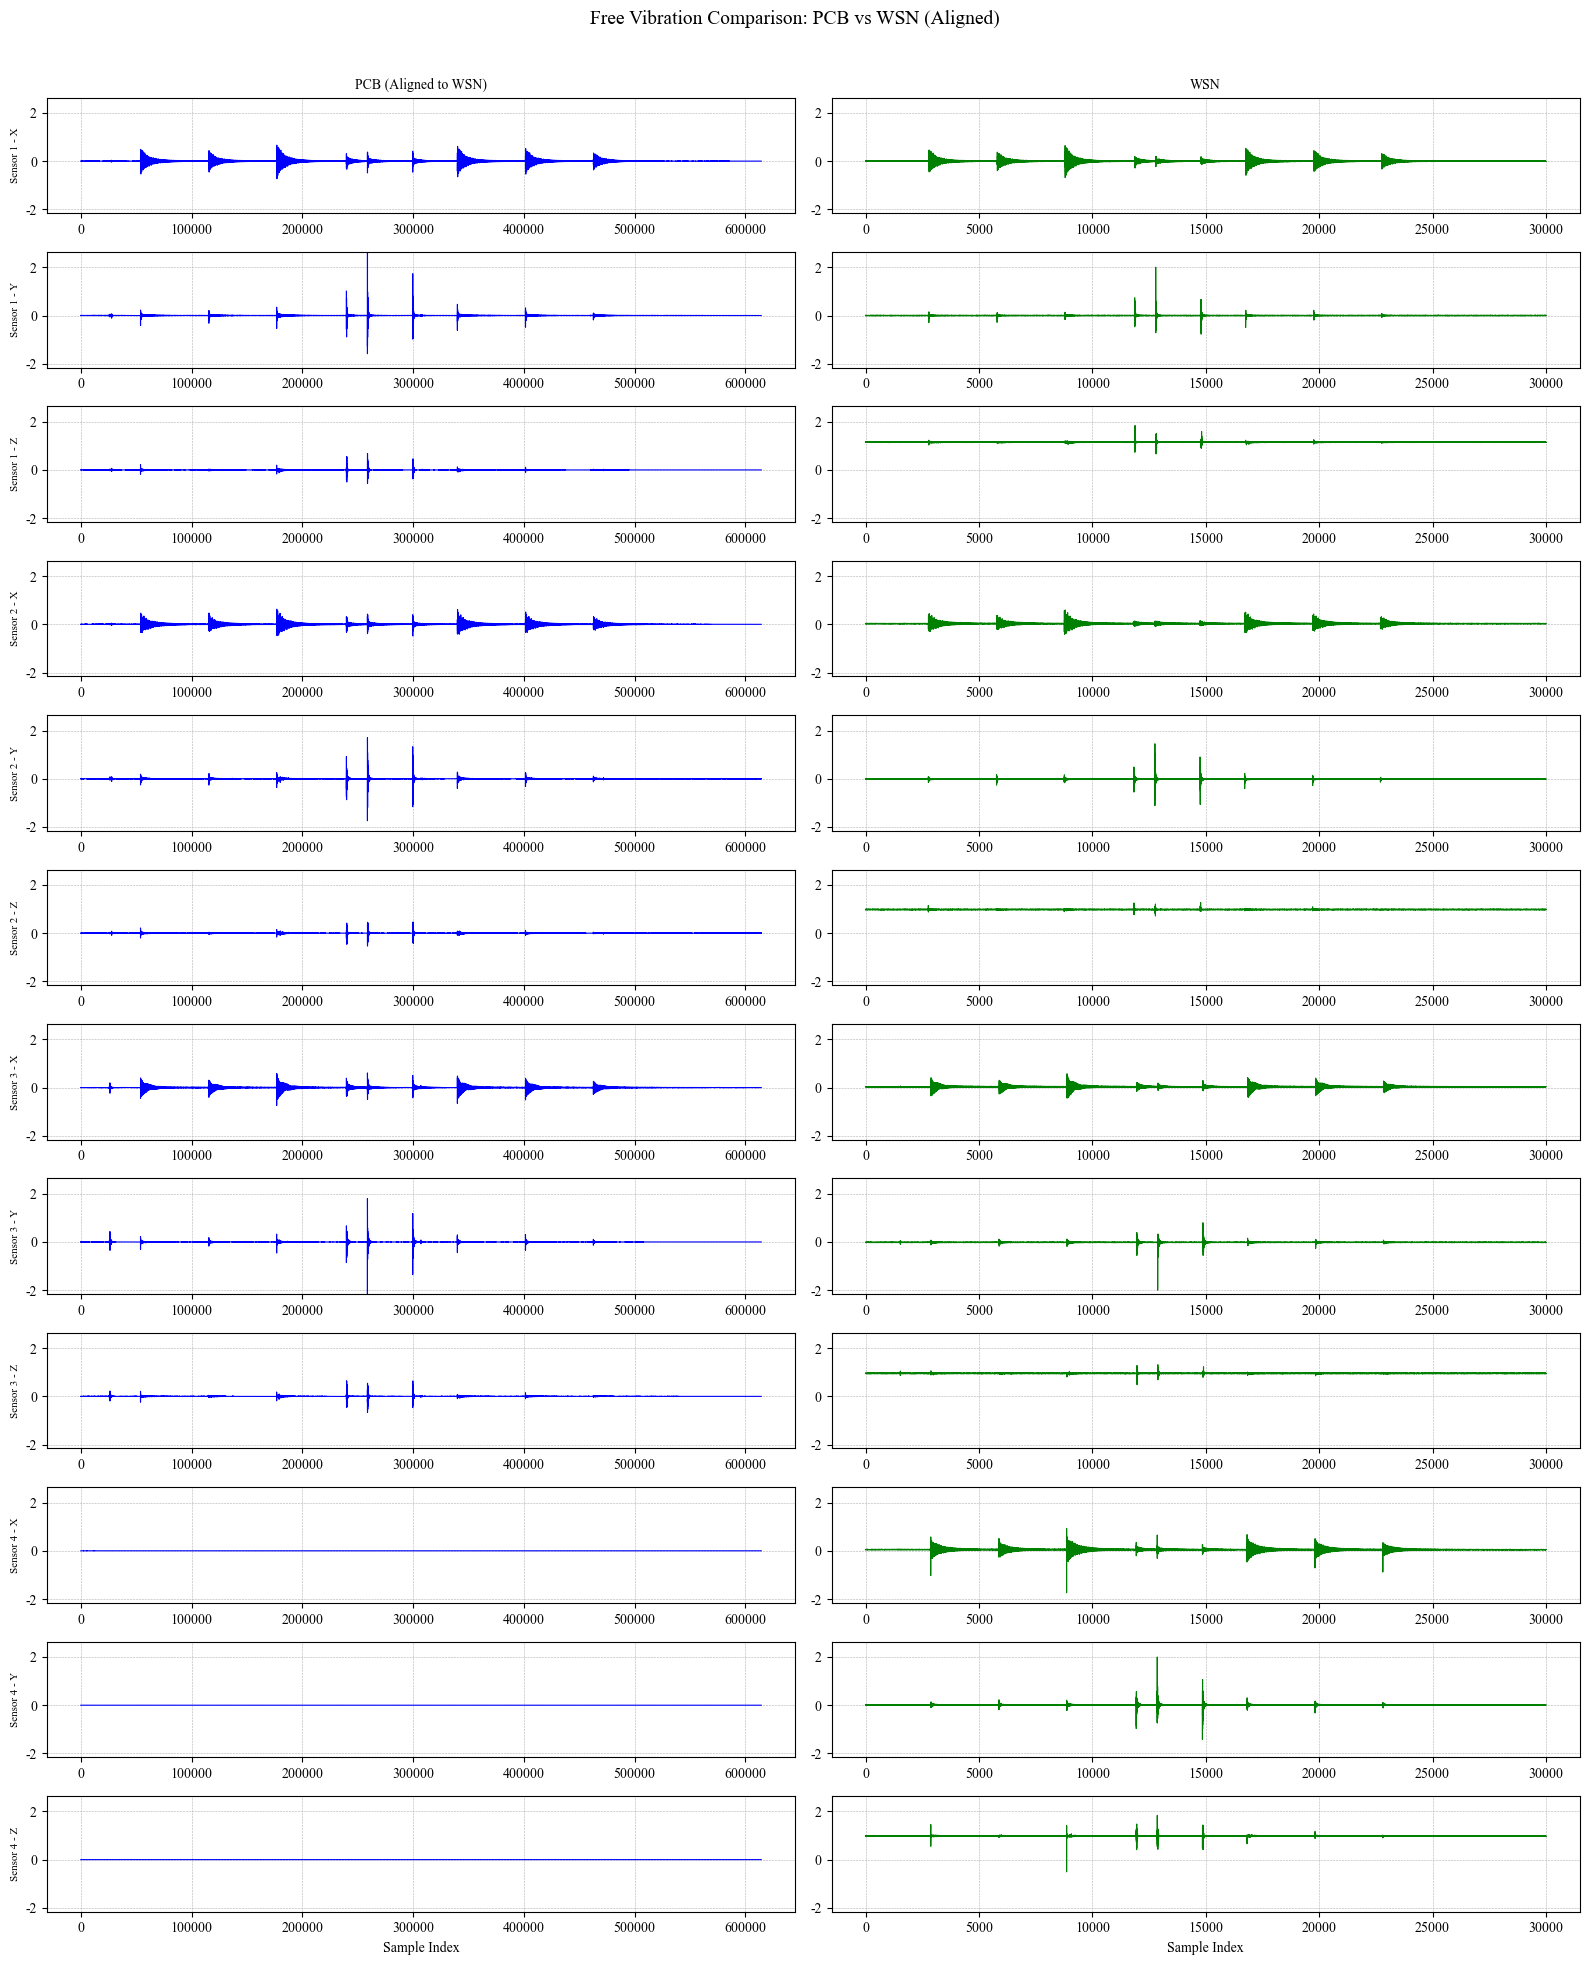

In [21]:
# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Time Axes (independent) ===
time_pcb = np.arange(free_pcb_aligned.shape[0])
time_wsn = np.arange(free_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Global Y Axis Range for Consistency ===
y_min = min(free_pcb_aligned.min(), free_wsn_aligned.min())
y_max = max(free_pcb_aligned.max(), free_wsn_aligned.max())

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB
    axes[i, 0].plot(time_pcb, free_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn, free_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Free Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


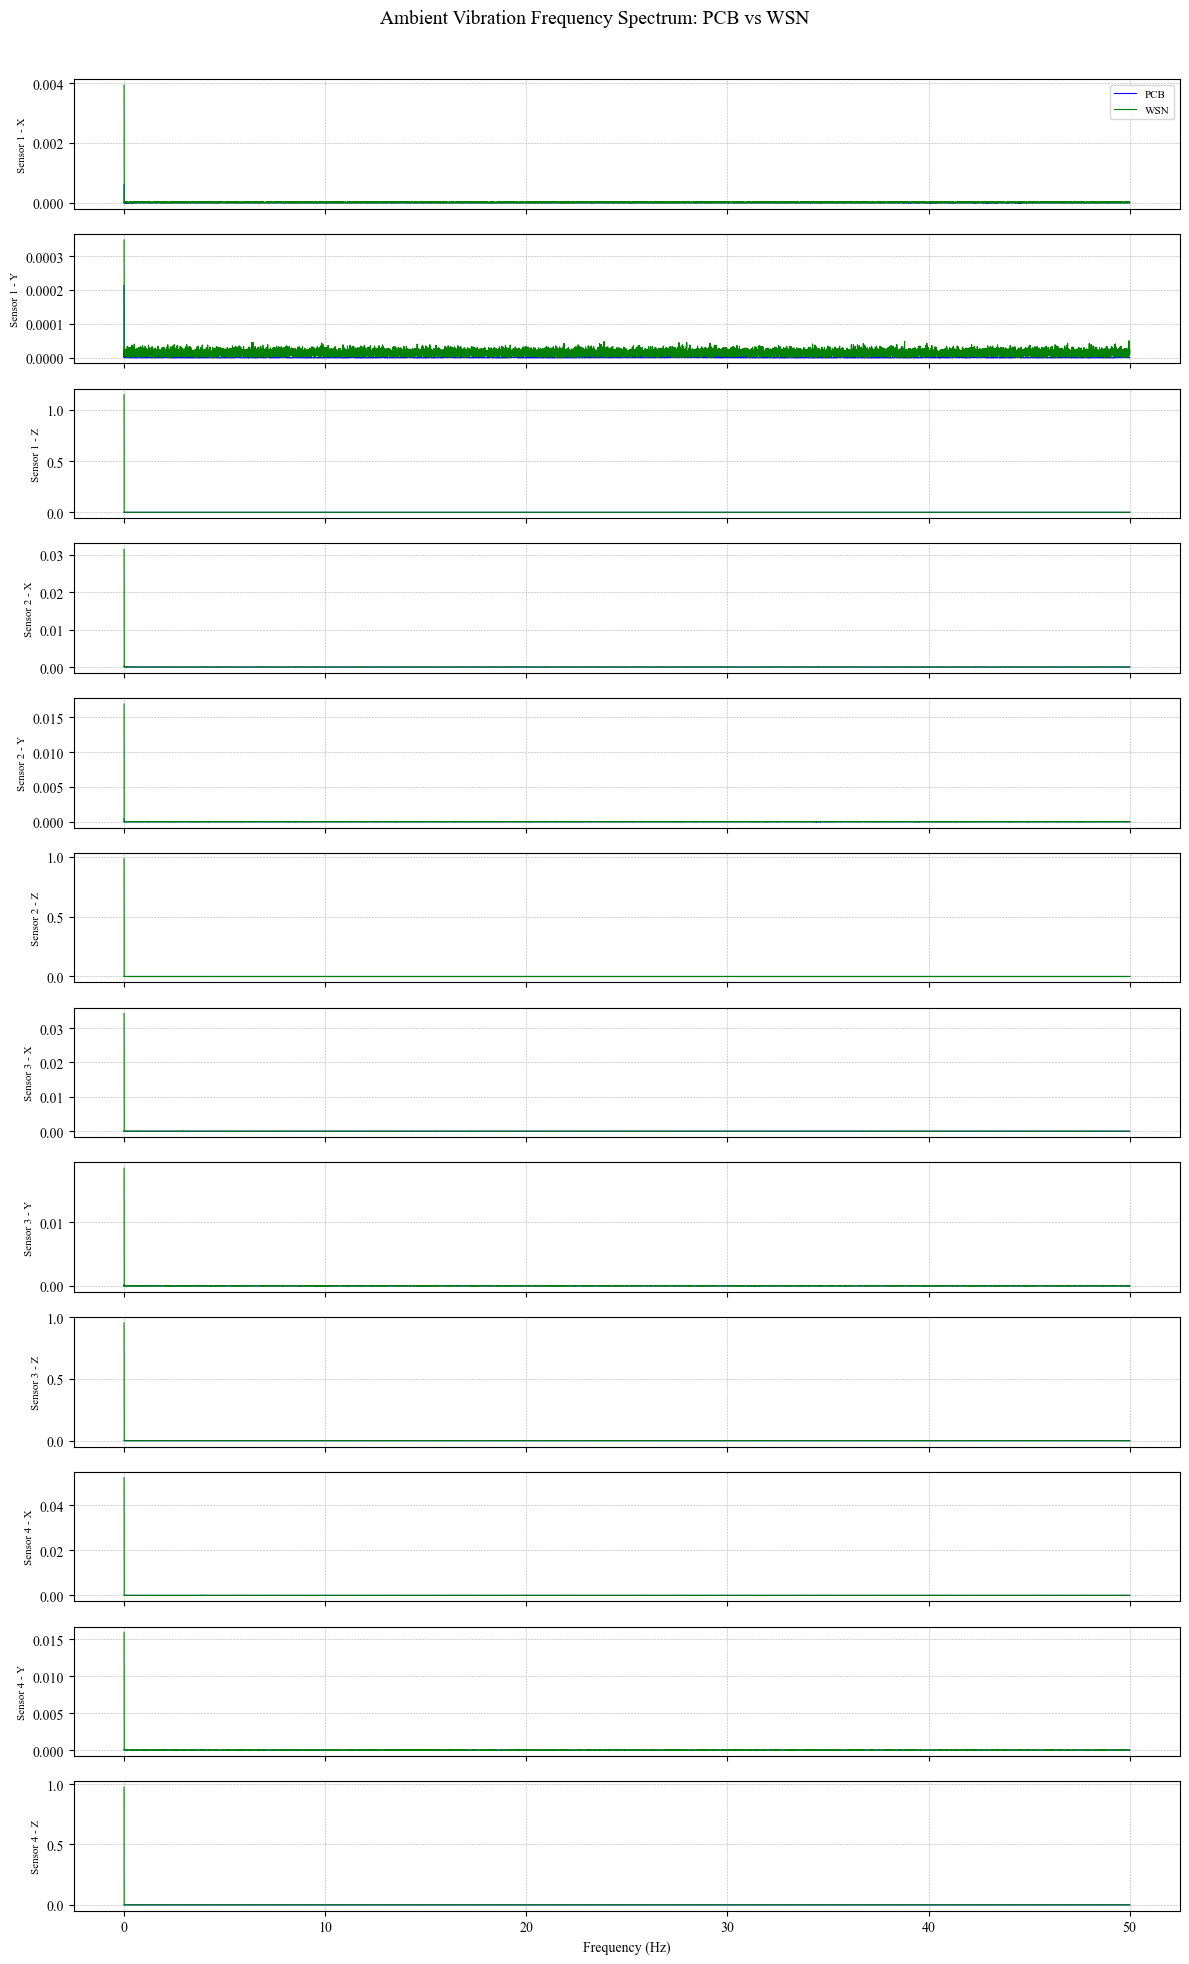

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.fft import rfft, rfftfreq

# === Font ===
rcParams['font.family'] = 'Times New Roman'

# === Sampling Rate ===
fs_pcb = 100  # Hz
fs_wsn = 100  # Hz

# === FFT Function (magnitude spectrum) ===
def compute_fft(signal, fs):
    N = len(signal)
    freq = rfftfreq(N, d=1/fs)
    fft_mag = np.abs(rfft(signal)) / N
    return freq, fft_mag

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot ===
fig, axes = plt.subplots(12, 1, figsize=(12, 20), sharex=True)

for i in range(12):
    # FFT for PCB
    freq_pcb, mag_pcb = compute_fft(am_pcb_aligned[:, i], fs_pcb)
    # FFT for WSN
    freq_wsn, mag_wsn = compute_fft(am_wsn_aligned[:, i], fs_wsn)

    # Frequency mask up to 50 Hz
    mask_pcb = freq_pcb <= 50
    mask_wsn = freq_wsn <= 50

    axes[i].plot(freq_pcb[mask_pcb], mag_pcb[mask_pcb], label='PCB', color='blue', linewidth=0.8)
    axes[i].plot(freq_wsn[mask_wsn], mag_wsn[mask_wsn], label='WSN', color='green', linewidth=0.8)
    axes[i].set_ylabel(channel_labels[i], fontsize=8)
    axes[i].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i].legend(fontsize=8)
    
axes[-1].set_xlabel("Frequency (Hz)", fontsize=10)
fig.suptitle("Ambient Vibration Frequency Spectrum: PCB vs WSN", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


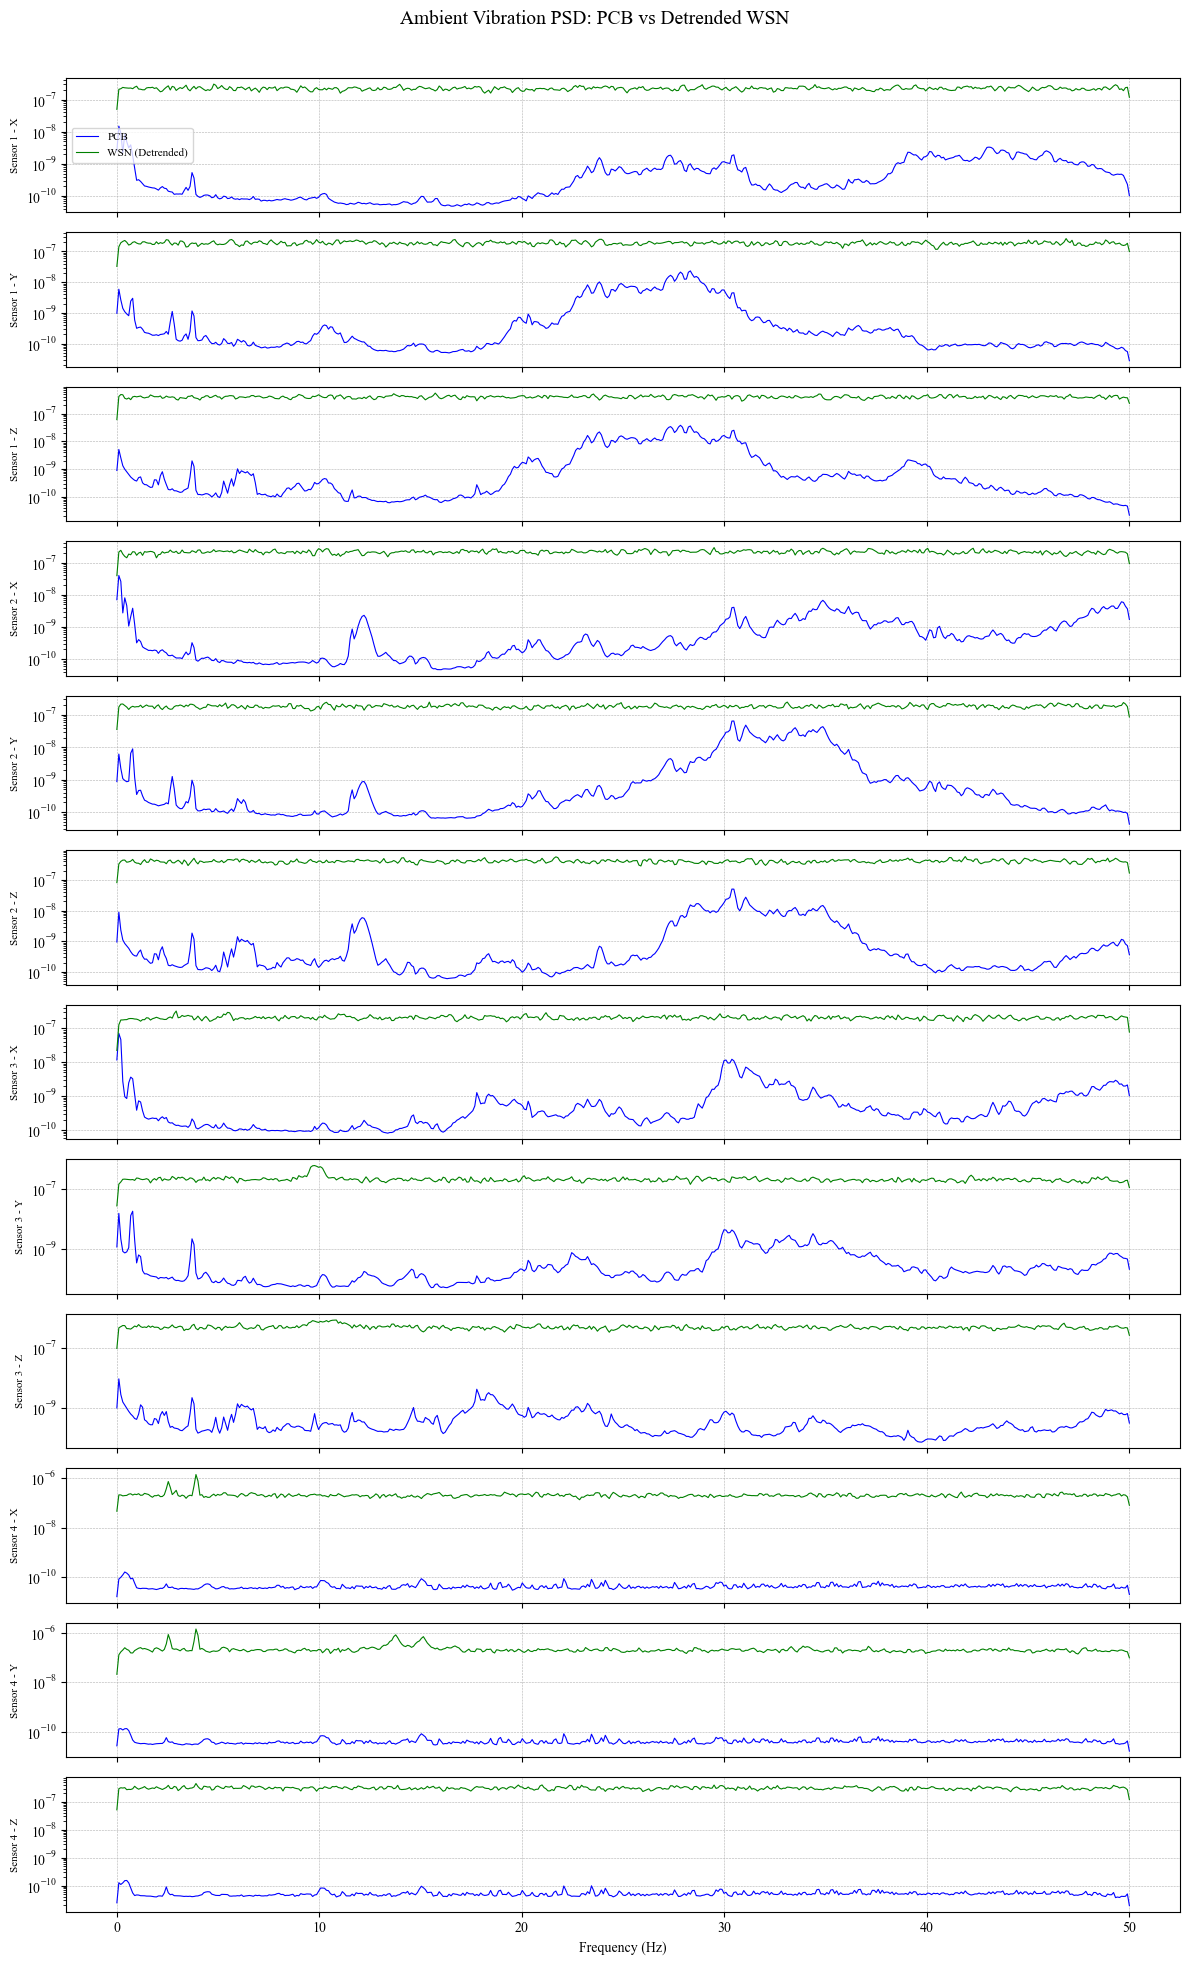

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import detrend, welch

# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Sampling Rate ===
fs = 100  # Hz

# === Detrend WSN ===
am_wsn_detrended = detrend(am_wsn_aligned, axis=0, type='linear')

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot: 12 rows, 1 column ===
fig, axes = plt.subplots(12, 1, figsize=(12, 20), sharex=True)

for i in range(12):
    # PSD for PCB
    f_pcb, Pxx_pcb = welch(am_pcb_aligned[:, i], fs=fs, nperseg=1024)
    # PSD for WSN (detrended)
    f_wsn, Pxx_wsn = welch(am_wsn_detrended[:, i], fs=fs, nperseg=1024)

    # Limit to 0–50 Hz
    mask_pcb = f_pcb <= 50
    mask_wsn = f_wsn <= 50

    axes[i].semilogy(f_pcb[mask_pcb], Pxx_pcb[mask_pcb], label="PCB", color='blue', linewidth=0.8)
    axes[i].semilogy(f_wsn[mask_wsn], Pxx_wsn[mask_wsn], label="WSN (Detrended)", color='green', linewidth=0.8)
    axes[i].set_ylabel(channel_labels[i], fontsize=8)
    axes[i].grid(True, linestyle='--', linewidth=0.4)
    
    if i == 0:
        axes[i].legend(fontsize=8)

axes[-1].set_xlabel("Frequency (Hz)", fontsize=10)
fig.suptitle("Ambient Vibration PSD: PCB vs Detrended WSN", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


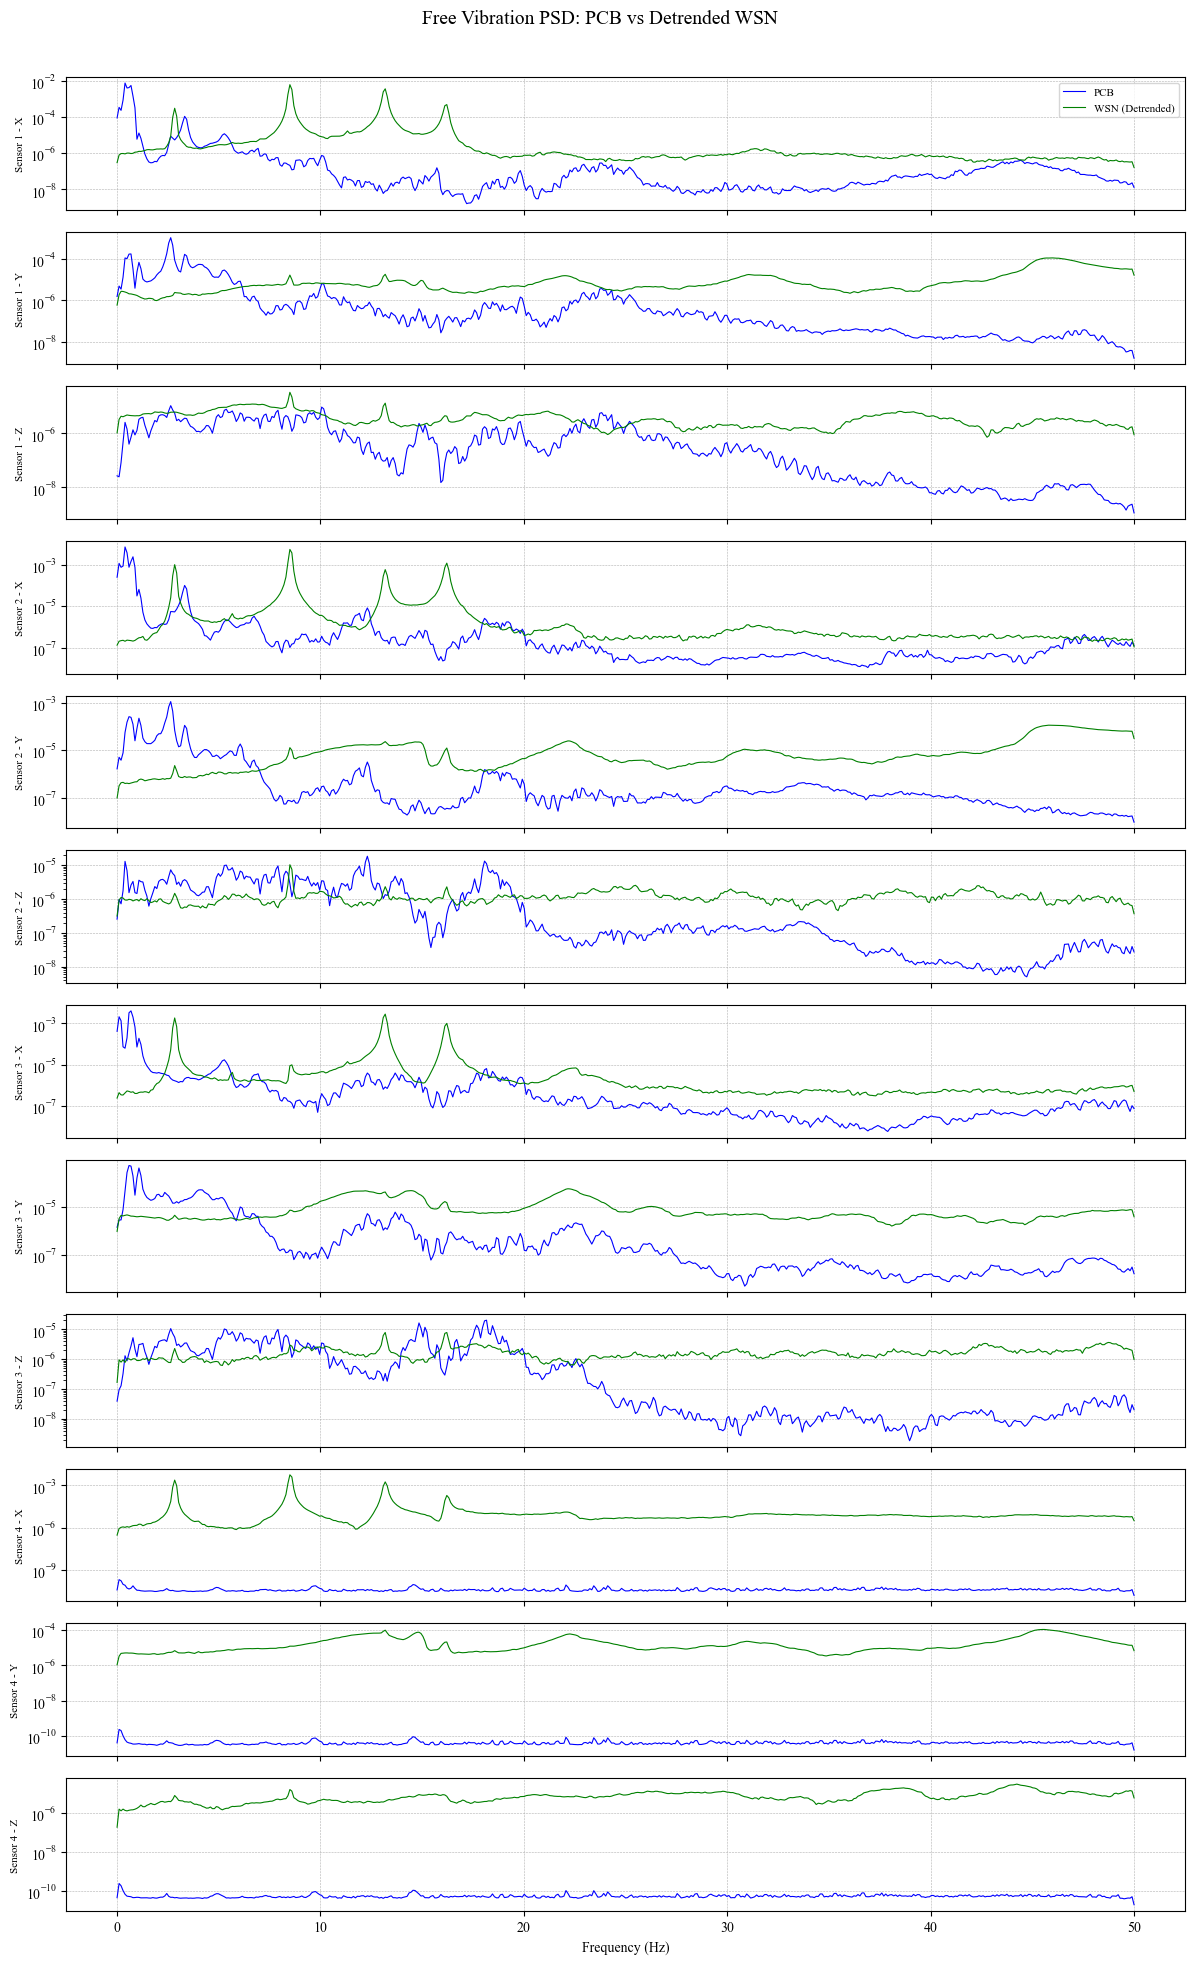

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import detrend, welch

# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Sampling Rate ===
fs = 100  # Hz (假设值，请替换为你真实采样率)

# === Detrend WSN data ===
free_wsn_detrended = detrend(free_wsn_aligned, axis=0, type='linear')

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot PSD Comparison ===
fig, axes = plt.subplots(12, 1, figsize=(12, 20), sharex=True)

for i in range(12):
    # PSD: PCB
    f_pcb, Pxx_pcb = welch(free_pcb_aligned[:, i], fs=fs, nperseg=1024)
    # PSD: WSN (detrended)
    f_wsn, Pxx_wsn = welch(free_wsn_detrended[:, i], fs=fs, nperseg=1024)

    # Limit to 0–50 Hz
    mask_pcb = f_pcb <= 50
    mask_wsn = f_wsn <= 50

    # Plot
    axes[i].semilogy(f_pcb[mask_pcb], Pxx_pcb[mask_pcb], label="PCB", color='blue', linewidth=0.8)
    axes[i].semilogy(f_wsn[mask_wsn], Pxx_wsn[mask_wsn], label="WSN (Detrended)", color='green', linewidth=0.8)
    axes[i].set_ylabel(channel_labels[i], fontsize=8)
    axes[i].grid(True, linestyle='--', linewidth=0.4)

    if i == 0:
        axes[i].legend(fontsize=8)

axes[-1].set_xlabel("Frequency (Hz)", fontsize=10)
fig.suptitle("Free Vibration PSD: PCB vs Detrended WSN", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


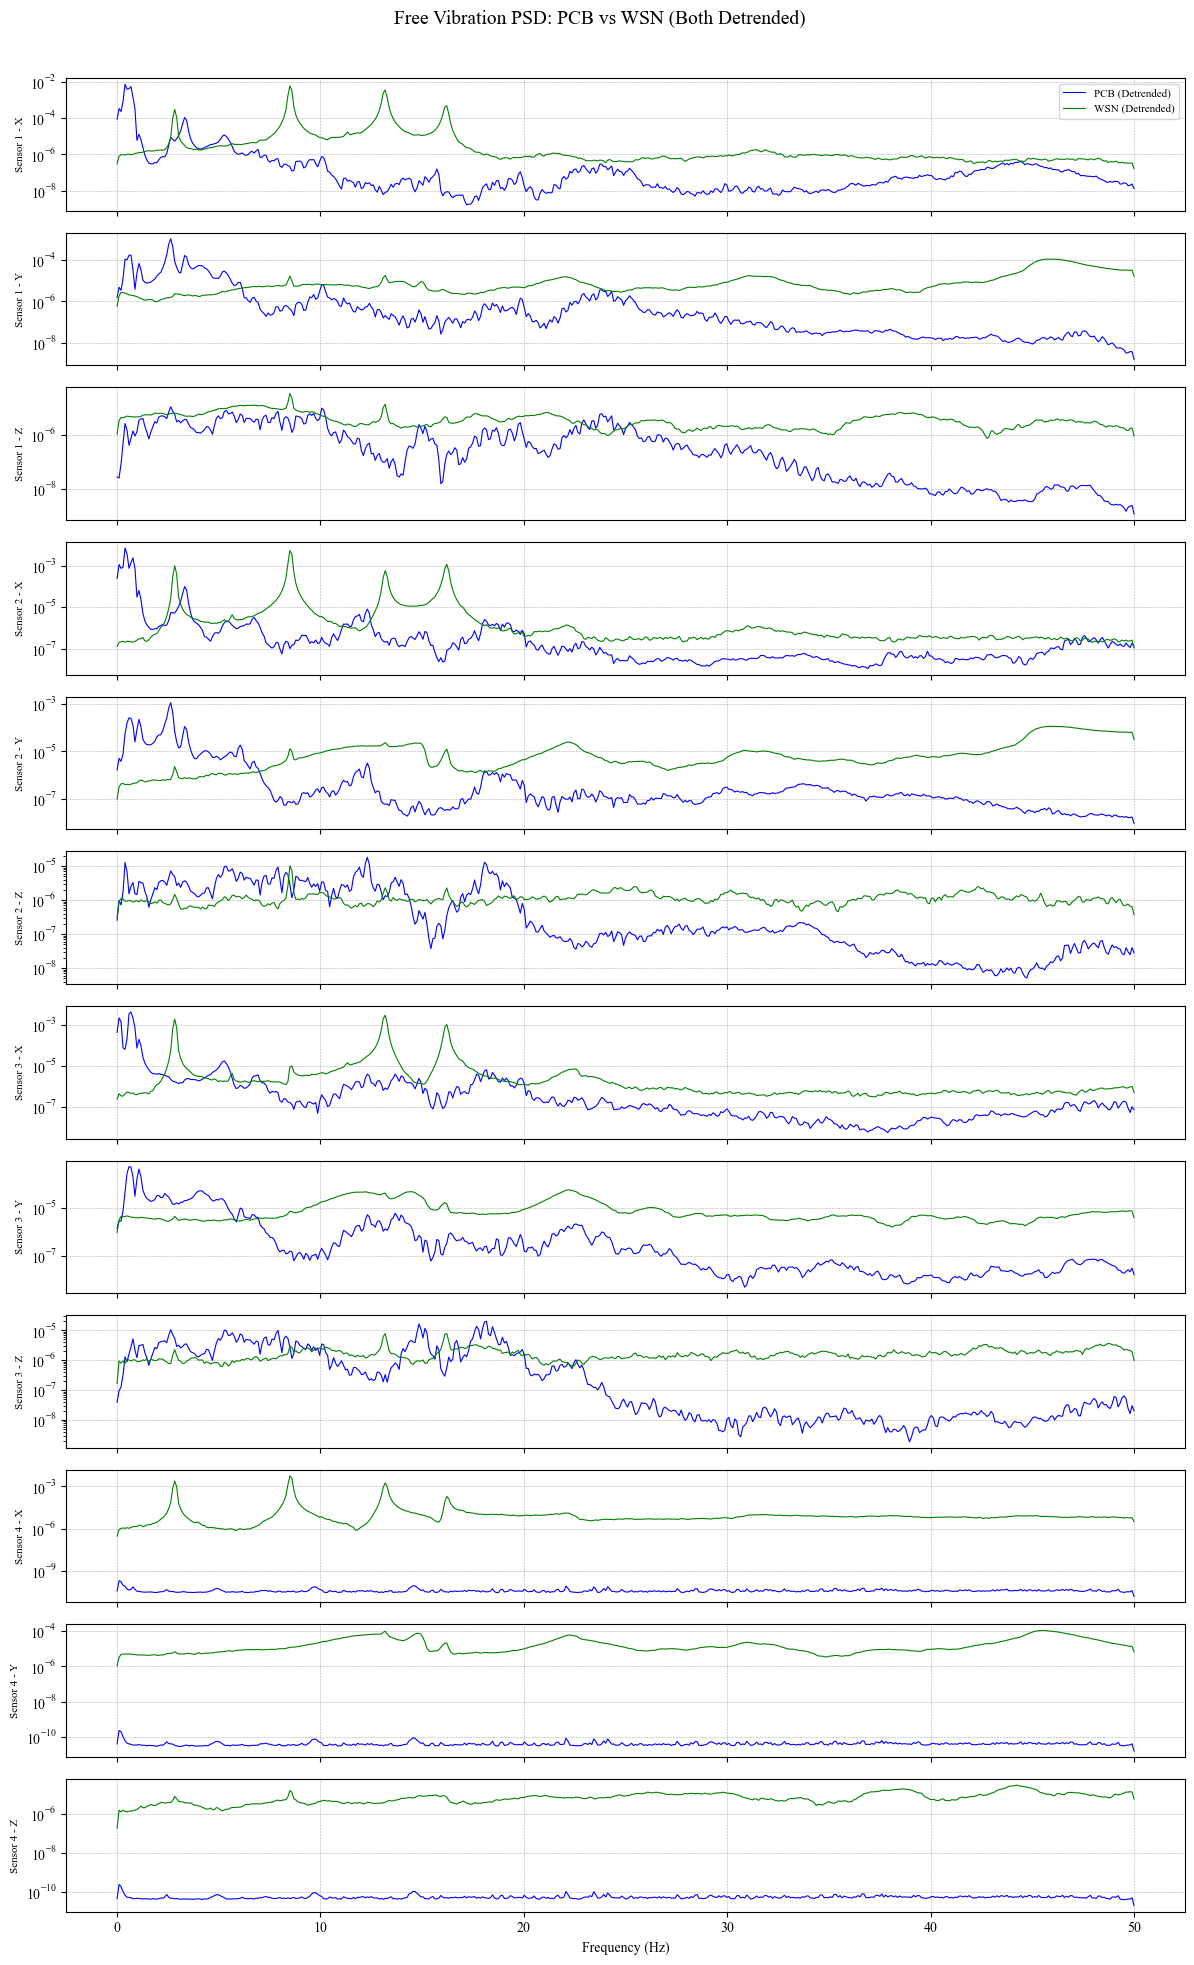

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import detrend, welch

# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Sampling Rate ===
fs = 100  # Hz

# === Detrend both PCB and WSN data ===
free_pcb_detrended = detrend(free_pcb_aligned, axis=0, type='linear')
free_wsn_detrended = detrend(free_wsn_aligned, axis=0, type='linear')

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot PSD Comparison (Both Detrended) ===
fig, axes = plt.subplots(12, 1, figsize=(12, 20), sharex=True)

for i in range(12):
    # Welch PSD
    f_pcb, Pxx_pcb = welch(free_pcb_detrended[:, i], fs=fs, nperseg=1024)
    f_wsn, Pxx_wsn = welch(free_wsn_detrended[:, i], fs=fs, nperseg=1024)

    # Frequency mask: 0–50 Hz
    mask_pcb = f_pcb <= 50
    mask_wsn = f_wsn <= 50

    # Plot
    axes[i].semilogy(f_pcb[mask_pcb], Pxx_pcb[mask_pcb], label="PCB (Detrended)", color='blue', linewidth=0.8)
    axes[i].semilogy(f_wsn[mask_wsn], Pxx_wsn[mask_wsn], label="WSN (Detrended)", color='green', linewidth=0.8)
    axes[i].set_ylabel(channel_labels[i], fontsize=8)
    axes[i].grid(True, linestyle='--', linewidth=0.4)

    if i == 0:
        axes[i].legend(fontsize=8)

axes[-1].set_xlabel("Frequency (Hz)", fontsize=10)
fig.suptitle("Free Vibration PSD: PCB vs WSN (Both Detrended)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
